In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing(as_frame=True)
X = housing.data
y = housing.target
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


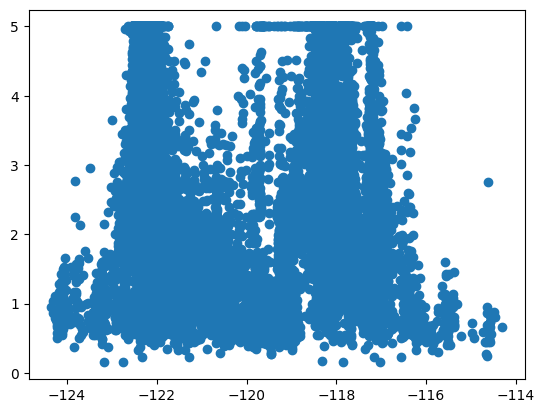

In [3]:
import matplotlib.pyplot as plt
plt.scatter(X['Longitude'], y)

In [4]:
X.isna().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64

In [5]:
y.isna().sum()

np.int64(0)

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [7]:
y_train.head()

14196    1.030
8267     3.821
17445    1.726
14265    0.934
2271     0.965
Name: MedHouseVal, dtype: float64

In [8]:
y_train

14196    1.030
8267     3.821
17445    1.726
14265    0.934
2271     0.965
         ...  
11284    2.292
11964    0.978
5390     2.221
860      2.835
15795    3.250
Name: MedHouseVal, Length: 16512, dtype: float64

<Axes: >

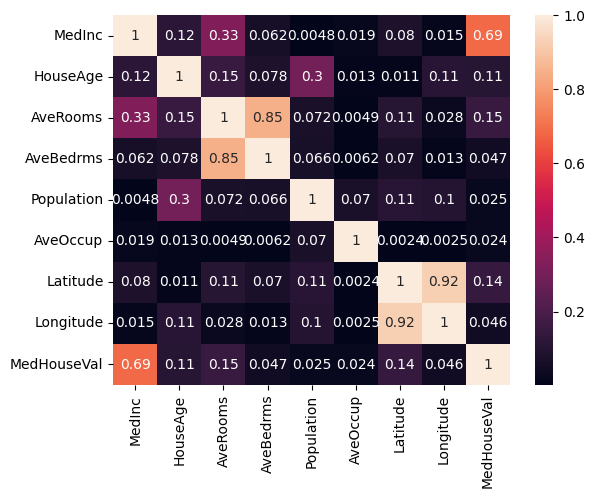

In [9]:
import seaborn as sns
df_train = X.join(y)
sns.heatmap(df_train.corr().abs(), annot=True)

In [10]:
X_train_scaled = (X_train - X_train.mean())/X_train.std()
X_test_scaled = (X_test - X_train.mean())/X_train.std()

In [35]:
import math
from sklearn.metrics import mean_squared_error
def linear_calc(X, w, b):
    # X: matrix of shape (m examples, n features)
    # w: vector of shape (n features,)
    # returns: vector of predictions, shape (m,)
    return X.dot(w) + b
def mse(y_pred, y_target, length):
    return (sum((y_pred - y_target)**2))/length
def update_weights(y_target, X_column, y_pred, length, w, b, lr):
    #print(f"Error: {mse(y_pred, y_target, length)}")
    
    error = y_pred - y_target
    
    w_gradient = (2 * X_column.T.dot(error)) / length
    b_gradient = (2 * sum(error)) / length
    
    #print(f"Pred: {y_pred}")
    #print(f"Target: {y_target}")
    #print(f"Length: {length}")
    #print(f"w_gradient: {w_gradient}")
    #print(f"b_gradient: {b_gradient}")
    
    w = w - lr * w_gradient
    b = b - lr * b_gradient
    
    #print(f"w: {w}")
    #print(f"b: {b}")
    
    return w, b

epochs = 100
n_features = X_train_scaled.shape[1]
w = np.zeros(n_features)
b = 0.0
lr = 0.1
cost_history = []
for _ in range(epochs):
    y_pred = linear_calc(X_train_scaled, w, b)
    cost_history.append(mse(y_pred, y_train, X_train_scaled.shape[0]))
    w, b = update_weights(y_train, X_train_scaled, y_pred, X_train_scaled.shape[0], w, b, lr)

preds = linear_calc(X_test_scaled, w, b)
print(mean_squared_error(preds, y_test))

0.5545759899430578


In [21]:
#Importing sklearn for predictions
from sklearn.linear_model import LinearRegression
sklinear = LinearRegression()
sklinear.fit(X_train_scaled, y_train)
preds = sklinear.predict(X_test_scaled)
print(mean_squared_error(preds, y_test))

0.5558915986952442
